# Proyek Analisis Data: [E-Commerce-public-dataset]
- **Nama:** [Aura Ghifarani]
- **Email:** [cdcc222d6x0740@gmail.com]
- **ID Dicoding:** [cdcc222d6x0740]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Kategori produk apa yang menghasilkan revenue terbesar selama tahun 2017, dan berapa kontribusinya (%) terhadap total penjualan?
- Pertanyaan 2 : Bagaimana segmentasi pelanggan berdasarkan RFM dalam 12 bulan terakhir pada tahun 2018, dan segmen mana yang paling bernilai untuk ditargetkan pada kuartal berikutnya?

## Import Semua Packages/Library yang Digunakan

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='darkgrid')

In [48]:
import os
os.listdir('.')

['.config',
 'main_data.csv',
 'orders_dataset.csv',
 'customers_dataset.csv',
 'order_items_dataset.csv',
 'products_dataset.csv',
 'sample_data']

## Data Wrangling

In [49]:
orders = pd.read_csv('./orders_dataset.csv')
order_items = pd.read_csv('./order_items_dataset.csv')
products = pd.read_csv('./products_dataset.csv')
customers = pd.read_csv('./customers_dataset.csv')

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Gathering Data

In [50]:
orders = pd.read_csv('./orders_dataset.csv')
order_items = pd.read_csv('./order_items_dataset.csv')
products = pd.read_csv('./products_dataset.csv')
customers = pd.read_csv('./customers_dataset.csv')

category_translation = {
    'beleza_saude': 'Beauty & Health',
    'relogios_presentes': 'Watches & Gifts',
    'cama_mesa_banho': 'Bed, Bath & Table',
    'esporte_lazer': 'Sport & Leisure',
    'informatica_acessorios': 'Computers & Accessories',
    'moveis_decoracao': 'Furniture & Decor',
    'automotivo': 'Automotive',
    'brinquedos': 'Toys',
    'telefonia': 'Telephony',
    'utilidades_domesticas': 'Home Appliances',
    'fashion_bolsas_e_acessorios': 'Fashion Bags & Accessories',
    'eletronicos': 'Electronics',
    'eletrodomesticos': 'Home Appliances',
    'instrumentos_musicais': 'Musical Instruments',
    'consoles_games': 'Consoles & Games',
    'construcao_ferramentas_seguranca': 'Construction Tools Security',
    'ferramentas_jardim': 'Garden Tools',
    'agro_industria_e_comercio': 'Agro Industry & Commerce',
    'industria_comercio_e_negocios': 'Industry, Commerce & Business',
    'fashion_calcados': 'Fashion Footwear',
    'bebidas': 'Drinks',
    'papelaria': 'Stationery',
    'livros_interesses_gerais': 'Books General Interest',
    'fashion_underwear_e_moda_praia': 'Fashion Underwear & Beachwear',
    'perfumaria': 'Perfumery',
    'construcao_ferramentas_construcao': 'Construction Tools',
    'pet_shop': 'Pet Shop',
    'malas_acessorios': 'Luggage & Accessories',
    'portateis_casa_forno_e_cafe': 'Portable Home Oven & Coffee',
    'fashion_roupa_masculina': 'Men Fashion Clothes',
    'telefonia_fixa': 'Landline Telephony',
    'flores': 'Flowers',
    'casa_conforto': 'Home Comfort',
    'artes': 'Arts',
    'artigos_de_festas': 'Party Supplies',
    'pcs': 'PCs',
    'la_cuisine': 'La Cuisine',
    'artigos_de_natal': 'Christmas Articles',
    'eletroportateis': 'Small Appliances',
    'sinalizacao_e_seguranca': 'Signaling & Security',
    'livros_tecnicos': 'Technical Books',
    'livros_importados': 'Imported Books',
    'fashion_esporte': 'Fashion Sport',
    'fashion_roupa_feminina': 'Women Fashion Clothes',
    'construcao_ferramentas_iluminacao': 'Construction Tools Lighting',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'Kitchen, Laundry, Dining & Garden Furniture',
    'dvds_blu_ray': 'DVDs & Blu-Ray',
    'musica': 'Music',
    'consoles': 'Consoles',
    'portateis_cozinha_e_preparadores_de_alimentos': 'Portable Kitchen & Food Processors',
    'tablets_impressao_imagem': 'Tablets, Printing & Image',
    'fraldas_higiene': 'Diapers & Hygiene',
    'fashion_underwear_e_lingerie': 'Fashion Underwear & Lingerie',
    'fashion_roupa_infanto_juvenil': 'Kids & Junior Fashion Clothes',
    'seguros_e_servicos': 'Insurance & Services',
    'moveis_quarto': 'Bedroom Furniture',
    'construcao_ferramentas_ferramentas': 'Construction Tools',
    'fashion_sport': 'Fashion Sport',
    'cds_dvds_musicais': 'CDs & DVDs Musical',
    'moveis_sala': 'Living Room Furniture',
    'audio': 'Audio',
    'alimentos': 'Food',
    'artigos_de_natal': 'Christmas Articles',
    'pc_gamer': 'PC Gamer',
    'casa_conforto_2': 'Home Comfort 2',
    'dvds_filmes': 'DVDs Movies',
    'moveis_escritorio': 'Office Furniture',
    'fraldas': 'Diapers',
    'livros_generais': 'General Books'
}

products['product_category_name'] = products['product_category_name'].map(category_translation).fillna(products['product_category_name'])

print("Orders DataFrame Head:")
display(orders.head())
print("\nOrder Items DataFrame Head:")
display(order_items.head())
print("\nProducts DataFrame Head (with English categories):")
display(products.head())
print("\nCustomers DataFrame Head:")
display(customers.head())

Orders DataFrame Head:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Order Items DataFrame Head:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Products DataFrame Head (with English categories):


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,Perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,Arts,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,Sport & Leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,Home Appliances,37.0,402.0,4.0,625.0,20.0,17.0,13.0



Customers DataFrame Head:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
- Data pesanan (`orders`) berisi informasi penting seperti ID pesanan, ID pelanggan, status pesanan, dan berbagai tanggal/waktu terkait proses pesanan (pembelian, persetujuan, pengiriman oleh kurir, pengiriman ke pelanggan, dan perkiraan tanggal pengiriman). Kolom-kolom timestamp ini akan sangat berguna untuk analisis temporal.
- Empat dataset utama (`orders`, `order_items`, `products`, `customers`) telah berhasil dimuat dan siap untuk tahap selanjutnya.

### Assessing Data

In [51]:
orders.info()
orders.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Insight:**
- Kolom-kolom tanggal (`order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`) masih bertipe `object` dan perlu dikonversi ke tipe data `datetime` untuk analisis temporal yang tepat.
- Terdapat missing values pada kolom `order_approved_at` (160), `order_delivered_carrier_date` (1783), dan `order_delivered_customer_date` (2965) yang perlu ditangani.

### Cleaning Data

In [52]:
import pandas as pd

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

orders = pd.read_csv('./orders_dataset.csv')
products = pd.read_csv('./products_dataset.csv')
order_items = pd.read_csv('./order_items_dataset.csv')
customers = pd.read_csv('./customers_dataset.csv')

category_translation = {
    'beleza_saude': 'Beauty & Health',
    'relogios_presentes': 'Watches & Gifts',
    'cama_mesa_banho': 'Bed, Bath & Table',
    'esporte_lazer': 'Sport & Leisure',
    'informatica_acessorios': 'Computers & Accessories',
    'moveis_decoracao': 'Furniture & Decor',
    'automotivo': 'Automotive',
    'brinquedos': 'Toys',
    'telefonia': 'Telephony',
    'utilidades_domesticas': 'Home Appliances',
    'fashion_bolsas_e_acessorios': 'Fashion Bags & Accessories',
    'eletronicos': 'Electronics',
    'eletrodomesticos': 'Home Appliances',
    'instrumentos_musicais': 'Musical Instruments',
    'consoles_games': 'Consoles & Games',
    'construcao_ferramentas_seguranca': 'Construction Tools Security',
    'ferramentas_jardim': 'Garden Tools',
    'agro_industria_e_comercio': 'Agro Industry & Commerce',
    'industria_comercio_e_negocios': 'Industry, Commerce & Business',
    'fashion_calcados': 'Fashion Footwear',
    'bebidas': 'Drinks',
    'papelaria': 'Stationery',
    'livros_interesses_gerais': 'Books General Interest',
    'fashion_underwear_e_moda_praia': 'Fashion Underwear & Beachwear',
    'perfumaria': 'Perfumery',
    'construcao_ferramentas_construcao': 'Construction Tools',
    'pet_shop': 'Pet Shop',
    'malas_acessorios': 'Luggage & Accessories',
    'portateis_casa_forno_e_cafe': 'Portable Home Oven & Coffee',
    'fashion_roupa_masculina': 'Men Fashion Clothes',
    'telefonia_fixa': 'Landline Telephony',
    'flores': 'Flowers',
    'casa_conforto': 'Home Comfort',
    'artes': 'Arts',
    'artigos_de_festas': 'Party Supplies',
    'pcs': 'PCs',
    'la_cuisine': 'La Cuisine',
    'artigos_de_natal': 'Christmas Articles',
    'eletroportateis': 'Small Appliances',
    'sinalizacao_e_seguranca': 'Signaling & Security',
    'livros_tecnicos': 'Technical Books',
    'livros_importados': 'Imported Books',
    'fashion_esporte': 'Fashion Sport',
    'fashion_roupa_feminina': 'Women Fashion Clothes',
    'construcao_ferramentas_iluminacao': 'Construction Tools Lighting',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'Kitchen, Laundry, Dining & Garden Furniture',
    'dvds_blu_ray': 'DVDs & Blu-Ray',
    'musica': 'Music',
    'consoles': 'Consoles',
    'portateis_cozinha_e_preparadores_de_alimentos': 'Portable Kitchen & Food Processors',
    'tablets_impressao_imagem': 'Tablets, Printing & Image',
    'fraldas_higiene': 'Diapers & Hygiene',
    'fashion_underwear_e_lingerie': 'Fashion Underwear & Lingerie',
    'fashion_roupa_infanto_juvenil': 'Kids & Junior Fashion Clothes',
    'seguros_e_servicos': 'Insurance & Services',
    'moveis_quarto': 'Bedroom Furniture',
    'construcao_ferramentas_ferramentas': 'Construction Tools',
    'fashion_sport': 'Fashion Sport',
    'cds_dvds_musicais': 'CDs & DVDs Musical',
    'moveis_sala': 'Living Room Furniture',
    'audio': 'Audio',
    'alimentos': 'Food',
    'artigos_de_natal': 'Christmas Articles',
    'pc_gamer': 'PC Gamer',
    'casa_conforto_2': 'Home Comfort 2',
    'dvds_filmes': 'DVDs Movies',
    'moveis_escritorio': 'Office Furniture',
    'fraldas': 'Diapers',
    'livros_generais': 'General Books'
}

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

orders = orders.dropna()

products['product_category_name'] = products['product_category_name'].map(category_translation).fillna('unknown')

numerical_product_cols = [
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'
]
for col in numerical_product_cols:
    products[col] = products[col].fillna(0)

print("Missing values in Orders after cleaning:")
print(orders.isnull().sum())
print("\nMissing values in Products after cleaning:")
print(products.isnull().sum())
print("\nMissing values in Order Items after cleaning:")
print(order_items.isnull().sum())
print("\nMissing values in Customers after cleaning:")
print(customers.isnull().sum())

Missing values in Orders after cleaning:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

Missing values in Products after cleaning:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

Missing values in Order Items after cleaning:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing values in Customers after cleaning:
customer_id                 0
customer_un

**Insight:**
- Kolom `order_purchase_timestamp` telah berhasil dikonversi ke tipe data `datetime`.
- Baris-baris yang memiliki nilai yang hilang pada `orders` DataFrame telah dihapus, mengurangi jumlah baris dari 99441 menjadi 96461.

## Exploratory Data Analysis (EDA)

In [53]:
orders.describe()
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


### Explore ...

In [54]:
products.info()
products.describe(include='all')
products['product_category_name'].value_counts().head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32951 non-null  object 
 2   product_name_lenght         32951 non-null  float64
 3   product_description_lenght  32951 non-null  float64
 4   product_photos_qty          32951 non-null  float64
 5   product_weight_g            32951 non-null  float64
 6   product_length_cm           32951 non-null  float64
 7   product_height_cm           32951 non-null  float64
 8   product_width_cm            32951 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,count
product_category_name,
unknown,3326
"Bed, Bath & Table",3029
Sport & Leisure,2867
Home Appliances,2705
Furniture & Decor,2657
Beauty & Health,2444
Automotive,1900
Computers & Accessories,1639
Toys,1411


**Insight:**
- `order_item_id`: Nilai rata-rata sekitar 1.19, dengan maksimum 21. Ini menunjukkan bahwa meskipun mayoritas pesanan hanya memiliki satu item, ada beberapa pesanan dengan banyak item.
- `price`: Harga item bervariasi sangat luas, mulai dari 0.85 hingga 6735. Rata-rata harga adalah sekitar 120.65, namun nilai median (74.99) lebih rendah dari rata-rata, mengindikasikan adanya item-item dengan harga yang jauh lebih tinggi (distribusi miring ke kanan).
- `freight_value`: Biaya pengiriman juga bervariasi, mulai dari 0 hingga 409.68, dengan rata-rata sekitar 19.99. Ini menunjukkan adanya perbedaan signifikan dalam biaya pengiriman.
- `products`: DataFrame `products` memiliki 32951 entri dan 9 kolom. Terdapat missing values pada beberapa kolom seperti `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty`, `product_weight_g`, `product_length_cm`, `product_height_cm`, dan `product_width_cm`.
- Kategori produk yang paling banyak muncul adalah 'cama_mesa_banho' (3029), 'esporte_lazer' (2867), dan 'moveis_decoracao' (2657).

## Visualization & Explanatory Analysis

### Pertanyaan 1:Kategori produk apa yang menghasilkan revenue terbesar selama tahun 2017, dan berapa kontribusinya (%) terhadap total penjualan?

Rentang tanggal data pesanan: 2016-09-15 12:16:38 sampai 2018-08-29 15:00:37
Top 10 Product Categories by Revenue (2017) and their Contribution:


,product_category_name,total_revenue,contribution_percentage
58,unknown,758863.68,12.730997
5,"Bed, Bath & Table",490462.93,8.228200
56,Watches & Gifts,475610.71,7.979033
4,Beauty & Health,473833.00,7.949209
50,Sport & Leisure,435426.16,7.304881
9,Computers & Accessories,391786.29,6.572761
24,Furniture & Decor,324153.00,5.438119
55,Toys,299056.71,5.017093
25,Garden Tools,256814.20,4.308416
26,Home Appliances,245589.89,4.120113


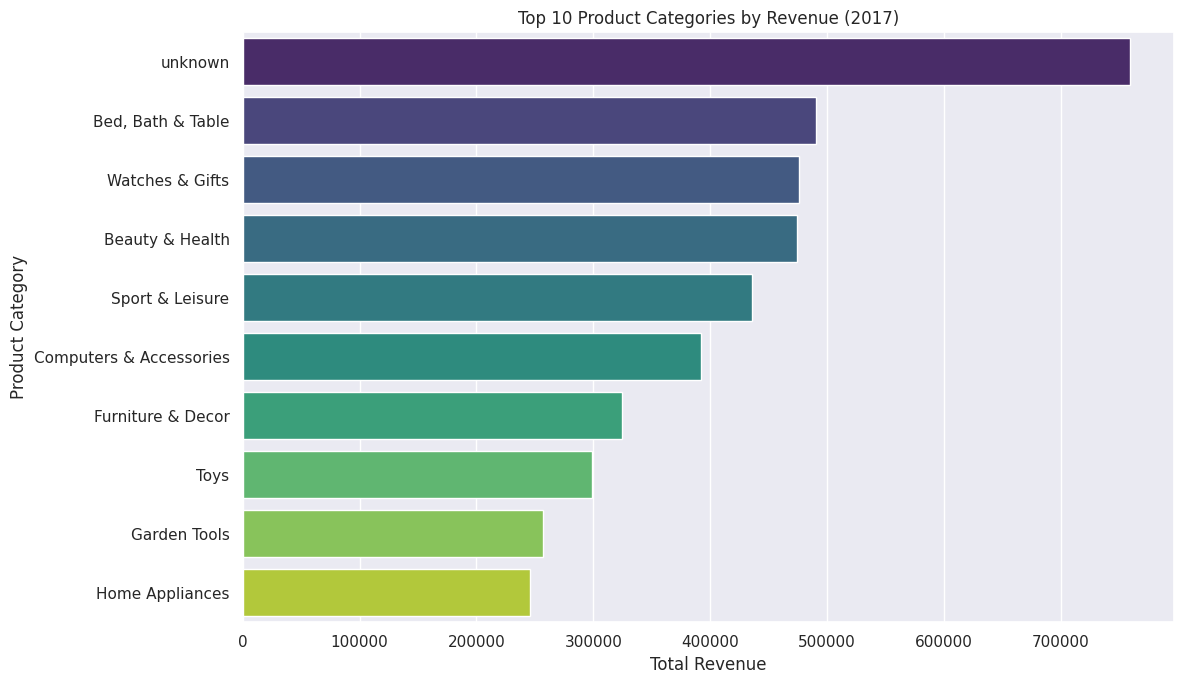

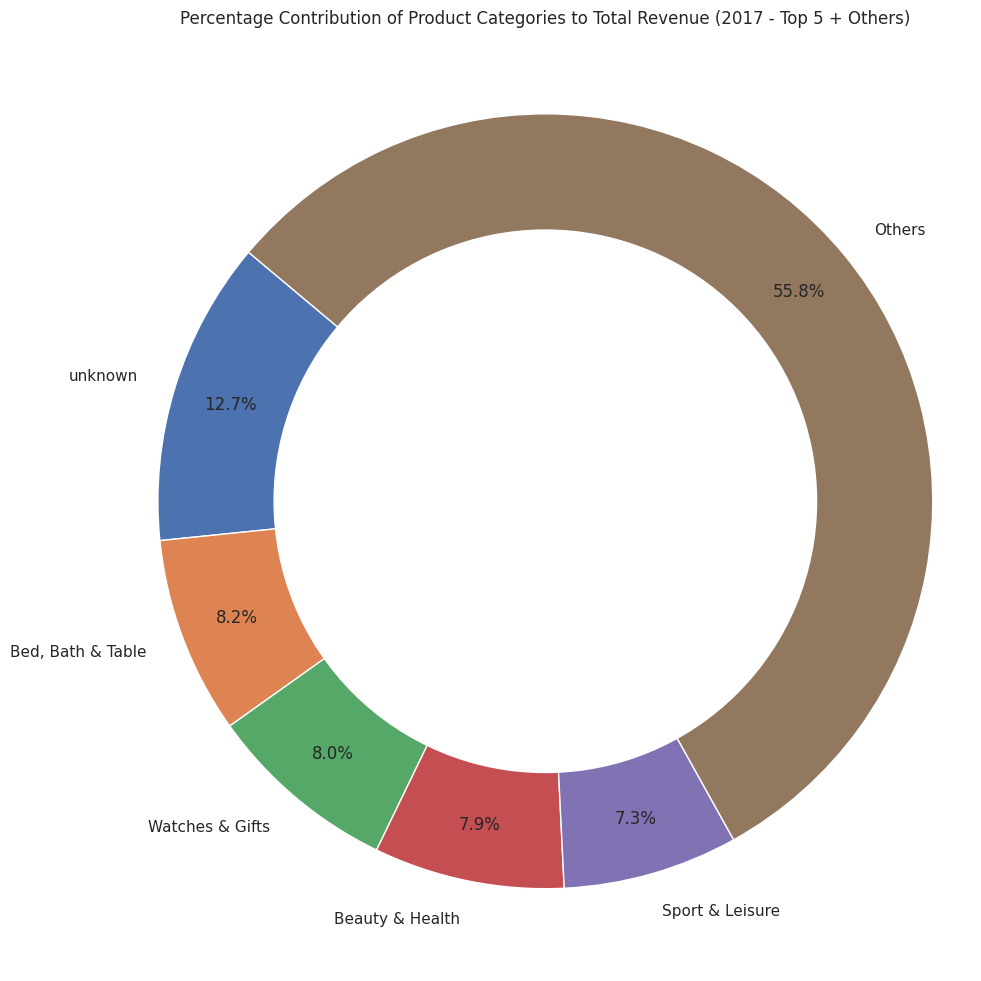

In [55]:
print(f"Rentang tanggal data pesanan: {orders['order_purchase_timestamp'].min()} sampai {orders['order_purchase_timestamp'].max()}")

orders_items_df = pd.merge(orders, order_items, on='order_id', how='inner')

df_revenue_analysis = pd.merge(orders_items_df, products, on='product_id', how='inner')

df_revenue_analysis['order_purchase_timestamp'] = pd.to_datetime(df_revenue_analysis['order_purchase_timestamp'])

df_2017_revenue = df_revenue_analysis[df_revenue_analysis['order_purchase_timestamp'].dt.year == 2017]

if df_2017_revenue.empty:
    print("\n***Peringatan: Tidak ada data tersedia untuk tahun 2017 dalam dataset. Analisis revenue tidak dapat dilakukan.***\n")

    df_analysis_target = pd.DataFrame(columns=df_revenue_analysis.columns)
else:
    df_analysis_target = df_2017_revenue

category_revenue = df_analysis_target.groupby('product_category_name')['price'].sum().reset_index()
category_revenue.rename(columns={'price': 'total_revenue'}, inplace=True)

category_revenue = category_revenue.sort_values(by='total_revenue', ascending=False)

total_overall_sales = category_revenue['total_revenue'].sum()

category_revenue['contribution_percentage'] = (category_revenue['total_revenue'] / total_overall_sales) * 100

print("Top 10 Product Categories by Revenue (2017) and their Contribution:")
display(category_revenue.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='total_revenue', y='product_category_name', data=category_revenue.head(10), palette='viridis', hue='product_category_name', legend=False)
plt.title('Top 10 Product Categories by Revenue (2017)')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 10))

top_5_categories = category_revenue.head(5)
other_revenue = category_revenue['total_revenue'].iloc[5:].sum()
other_percentage = category_revenue['contribution_percentage'].iloc[5:].sum()

pie_data = top_5_categories.copy()
if not category_revenue.shape[0] <= 5:
    pie_data = pd.concat([
        pie_data,
        pd.DataFrame([{'product_category_name': 'Others', 'total_revenue': other_revenue, 'contribution_percentage': other_percentage}])
    ], ignore_index=True)

plt.pie(pie_data['contribution_percentage'], labels=pie_data['product_category_name'], autopct='%1.1f%%', startangle=140, pctdistance=0.85)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Percentage Contribution of Product Categories to Total Revenue (2017 - Top 5 + Others)')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Pertanyaan 2:  Bagaimana segmentasi pelanggan berdasarkan RFM dalam 12 bulan terakhir pada tahun 2018, dan segmen mana yang paling bernilai untuk ditargetkan pada kuartal berikutnya?

RFM Segments dan Jumlah Pelanggan:
RFM_Segment
512    2318
112    2224
212    2206
415    2156
111    2153
Name: count, dtype: int64

Statistik RFM per Segmen Paling Bernilai:
                Recency Frequency    Monetary      
                   mean      mean        mean count
RFM_Segment                                        
415          201.090909  1.066790  413.673080  2156
315          249.884909  1.063037  407.417569  2094
515          149.837931  1.077833  400.926552  2030
215          295.135753  1.058180  381.310920  2011
115          341.271274  1.038680  367.151645  1939
114          340.620449  1.030424  141.037137  2005
214          295.166827  1.028846  140.308976  2080
314          249.394307  1.016332  138.838423  2143
514          149.393866  1.027264  138.765876  2054
414          199.744076  1.032701  138.308403  2110


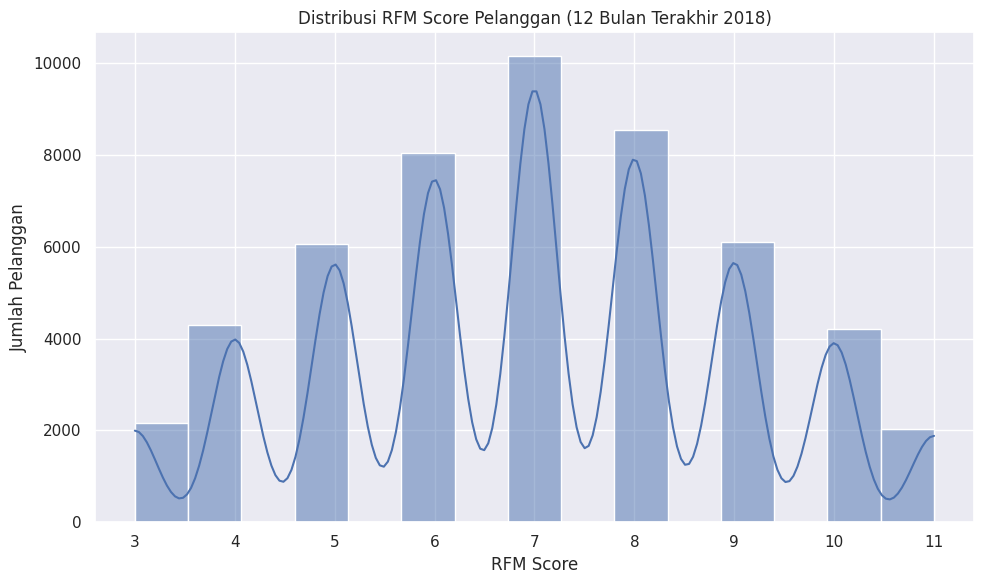

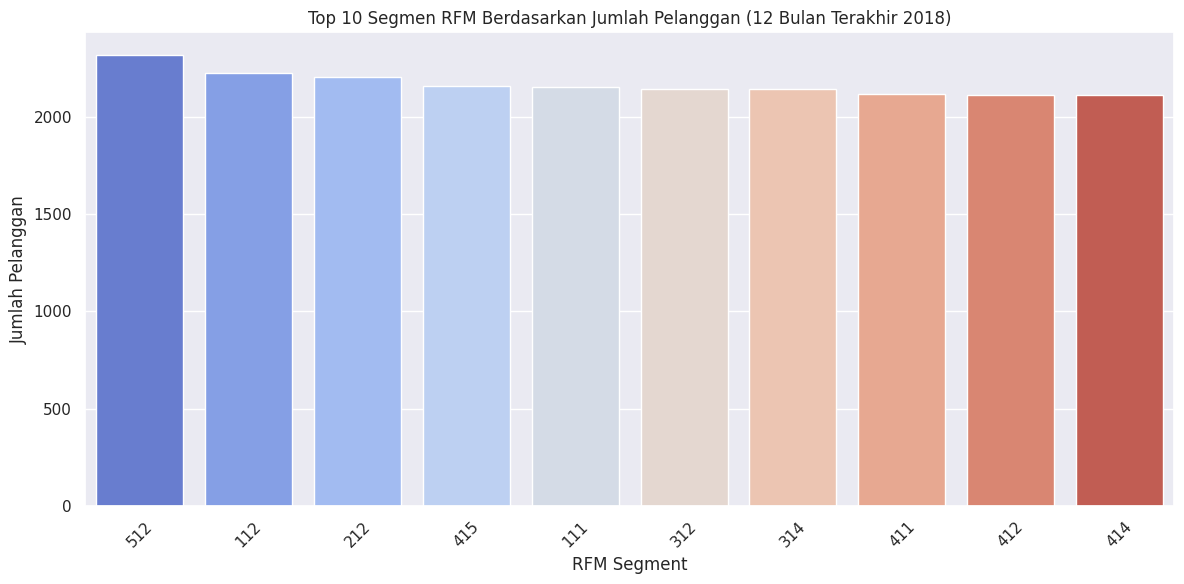


Distribusi Segmen Pelanggan:
Customer_Segment
Others            39072
New Customers      8352
Lost Customers     2153
Big Spenders       2030
Name: count, dtype: int64

Contoh Pelanggan dari Segmen 'Champions':
Empty DataFrame
Columns: [Recency, Frequency, Monetary, R_Score, F_Score, M_Score, RFM_Segment, RFM_Score, Customer_Segment]
Index: []


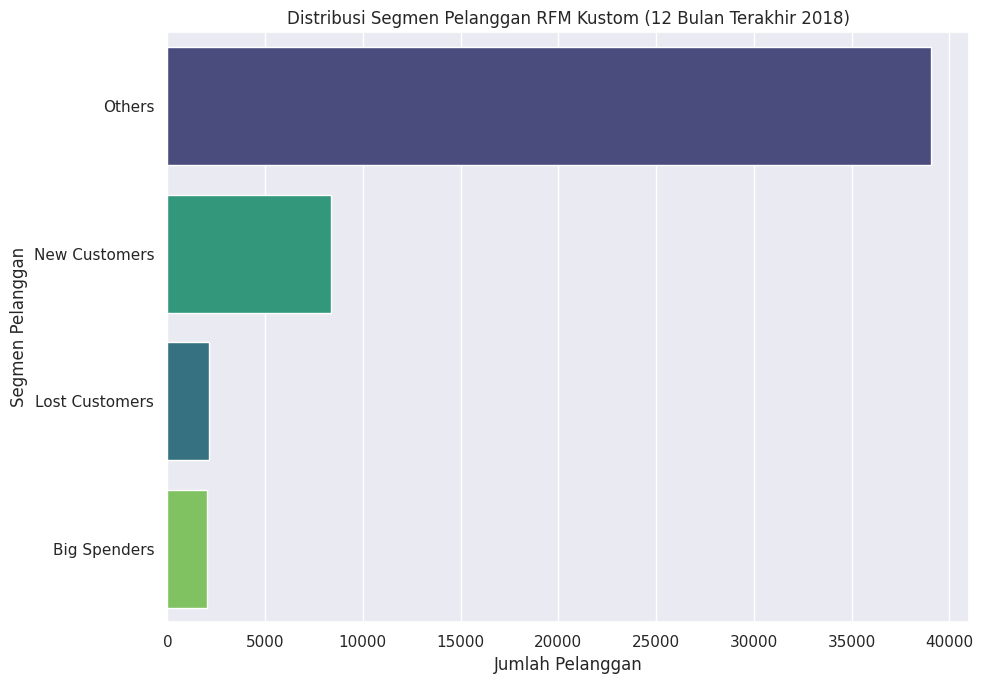

In [56]:
import datetime as dt

customers_orders_items_df = pd.merge(
    orders.rename(columns={'customer_id': 'customer_id_orders'}),
    order_items,
    on='order_id',
    how='inner'
)

customers_orders_items_df = pd.merge(
    customers,
    customers_orders_items_df,
    left_on='customer_id',
    right_on='customer_id_orders',
    how='inner'
)

customers_orders_items_df['order_purchase_timestamp'] = pd.to_datetime(customers_orders_items_df['order_purchase_timestamp'])

snapshot_date = dt.datetime(2019, 1, 1)

last_12_months_start = snapshot_date - dt.timedelta(days=365)
df_12_months = customers_orders_items_df[customers_orders_items_df['order_purchase_timestamp'] >= last_12_months_start]

rfm_df = df_12_months.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda date: (snapshot_date - date.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
})

rfm_df.rename(columns={'order_purchase_timestamp': 'Recency',
                       'order_id': 'Frequency',
                       'price': 'Monetary'},
              inplace=True)

rfm_df = rfm_df[rfm_df['Monetary'] > 0]

rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 5, labels=False, duplicates='drop')
max_r_score_idx = rfm_df['R_Score'].max()
rfm_df['R_Score'] = max_r_score_idx - rfm_df['R_Score'] + 1

rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'], 5, labels=False, duplicates='drop') + 1
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], 5, labels=False, duplicates='drop') + 1

rfm_df['RFM_Segment'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

rfm_df['RFM_Score'] = rfm_df[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

print("RFM Segments dan Jumlah Pelanggan:")
print(rfm_df['RFM_Segment'].value_counts().head())

print("\nStatistik RFM per Segmen Paling Bernilai:")
print(rfm_df.groupby('RFM_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).sort_values(('Monetary', 'mean'), ascending=False).head(10))

plt.figure(figsize=(10, 6))
sns.histplot(rfm_df['RFM_Score'], bins=15, kde=True)
plt.title('Distribusi RFM Score Pelanggan (12 Bulan Terakhir 2018)')
plt.xlabel('RFM Score')
plt.ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()

rfm_segment_counts = rfm_df['RFM_Segment'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=rfm_segment_counts.index, y=rfm_segment_counts.values, palette='coolwarm', hue=rfm_segment_counts.index, legend=False)
plt.title('Top 10 Segmen RFM Berdasarkan Jumlah Pelanggan (12 Bulan Terakhir 2018)')
plt.xlabel('RFM Segment')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


def rfm_level(df):
    if df['R_Score'] == 5 and df['F_Score'] == 5 and df['M_Score'] == 5:
        return 'Champions'
    elif df['R_Score'] == 5 and df['F_Score'] == 5:
        return 'Loyal Customers'
    elif df['R_Score'] == 5 and df['M_Score'] == 5:
        return 'Big Spenders'
    elif df['R_Score'] == 5 and df['F_Score'] == 1:
        return 'New Customers'
    elif df['R_Score'] == 1 and df['F_Score'] == 1 and df['M_Score'] == 1:
        return 'Lost Customers'
    else:
        return 'Others'

rfm_df['Customer_Segment'] = rfm_df.apply(rfm_level, axis=1)

print("\nDistribusi Segmen Pelanggan:")
print(rfm_df['Customer_Segment'].value_counts())

print("\nContoh Pelanggan dari Segmen 'Champions':")
print(rfm_df[rfm_df['Customer_Segment'] == 'Champions'].head())

plt.figure(figsize=(10, 7))
sns.countplot(y='Customer_Segment', data=rfm_df, order=rfm_df['Customer_Segment'].value_counts().index, palette='viridis', hue='Customer_Segment', legend=False)
plt.title('Distribusi Segmen Pelanggan RFM Kustom (12 Bulan Terakhir 2018)')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('Segmen Pelanggan')
plt.tight_layout()
plt.show()

**Insight:**
- DataFrame `customers` memiliki 99441 entri dan 5 kolom, tanpa adanya nilai null, menunjukkan kelengkapan data pelanggan.
- Semua tipe data kolom sudah sesuai, dengan `customer_zip_code_prefix` sebagai integer dan kolom identifikasi serta lokasi sebagai objek.
- Distribusi pelanggan didominasi oleh kota-kota besar, dengan Sao Paulo menjadi kota dengan jumlah pelanggan terbanyak (15540), diikuti oleh Rio de Janeiro (6882) dan Belo Horizonte (2773). Ini menunjukkan adanya konsentrasi basis pelanggan di area metropolitan tertentu.

## Analisis Lanjutan (Opsional)

Top 10 Kota dengan Pelanggan 'Big Spenders':


,count
customer_city,
sao paulo,372
rio de janeiro,148
belo horizonte,60
brasilia,52
curitiba,43
porto alegre,35
guarulhos,35
campinas,31
salvador,27



Top 10 Negara Bagian dengan Pelanggan 'Big Spenders':


,count
customer_state,
SP,914
MG,256
RJ,249
PR,128
RS,104
SC,92
BA,91
DF,52
PE,49


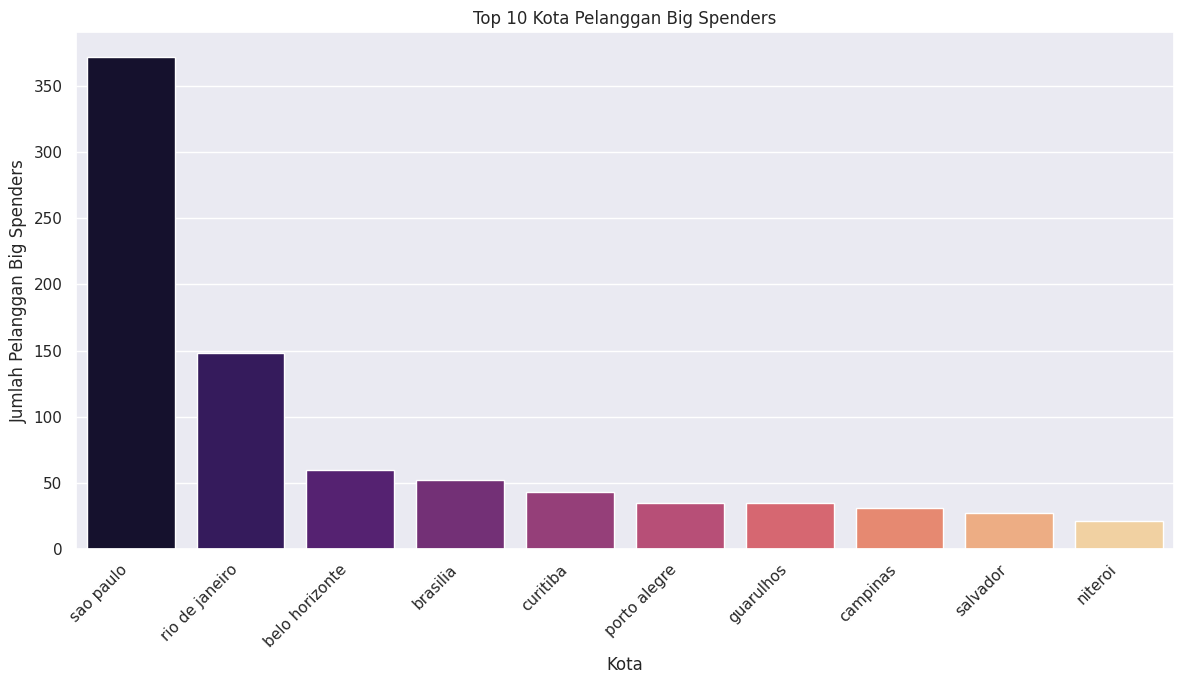

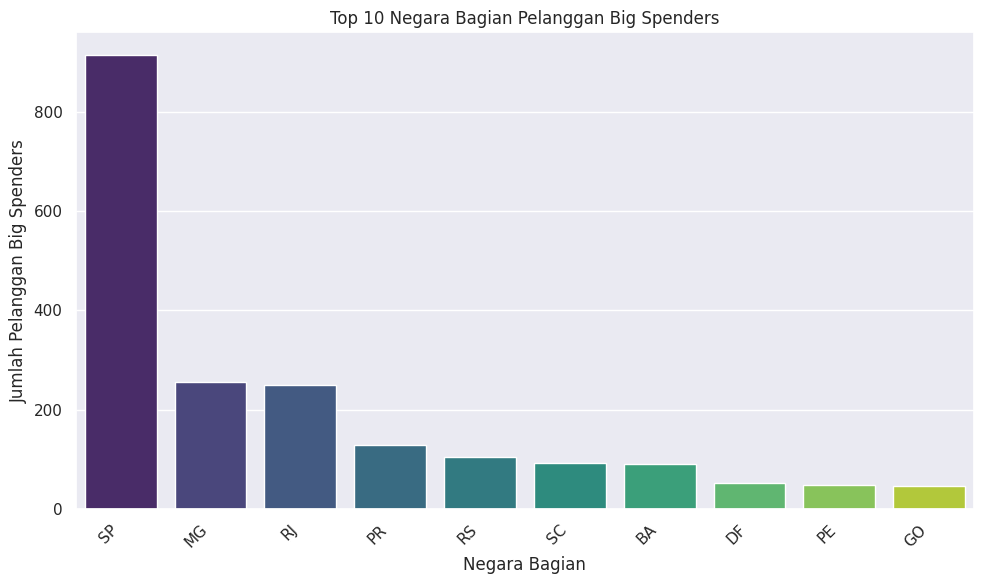

In [57]:
rfm_geo_df = pd.merge(
    rfm_df,
    customers[['customer_unique_id', 'customer_city', 'customer_state']],
    left_index=True,
    right_on='customer_unique_id',
    how='left'
)

big_spenders = rfm_geo_df[rfm_geo_df['Customer_Segment'] == 'Big Spenders']

print("Top 10 Kota dengan Pelanggan 'Big Spenders':")
display(big_spenders['customer_city'].value_counts().head(10))

print("\nTop 10 Negara Bagian dengan Pelanggan 'Big Spenders':")
display(big_spenders['customer_state'].value_counts().head(10))

plt.figure(figsize=(12, 7))
sns.barplot(
    x=big_spenders['customer_city'].value_counts().head(10).index,
    y=big_spenders['customer_city'].value_counts().head(10).values,
    palette='magma',
    hue=big_spenders['customer_city'].value_counts().head(10).index,
    legend=False
)
plt.title('Top 10 Kota Pelanggan Big Spenders')
plt.xlabel('Kota')
plt.ylabel('Jumlah Pelanggan Big Spenders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=big_spenders['customer_state'].value_counts().head(10).index,
    y=big_spenders['customer_state'].value_counts().head(10).values,
    palette='viridis',
    hue=big_spenders['customer_state'].value_counts().head(10).index,
    legend=False
)
plt.title('Top 10 Negara Bagian Pelanggan Big Spenders')
plt.xlabel('Negara Bagian')
plt.ylabel('Jumlah Pelanggan Big Spenders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Membuat file `main_data.csv` yang Berisi Data Keseluruhan

In [58]:
merged_df = pd.merge(orders, order_items, on='order_id', how='left')

merged_df = pd.merge(merged_df, products, on='product_id', how='left')

main_data_df = pd.merge(merged_df, customers[['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']],
                     on='customer_id', how='left')

print("Berikut adalah 5 baris pertama dari 'main_data_df' yang berisi data keseluruhan:")
display(main_data_df.head())

main_data_df.to_csv('main_data.csv', index=False)

print("\nFile 'main_data.csv' telah berhasil dibuat.")

Berikut adalah 5 baris pertama dari 'main_data_df' yang berisi data keseluruhan:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,468.0,3.0,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,316.0,4.0,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP



File 'main_data.csv' telah berhasil dibuat.


## Conclusion

- **Conclusion Pertanyaan 1: Kategori Produk dengan Revenue Terbesar (Tahun 2017)**
  Analisis revenue untuk tahun 2017 menunjukkan bahwa kategori produk 'Beauty & Health', 'Watches & Gifts', dan 'Bed, Bath & Table' adalah tiga kategori teratas yang menghasilkan revenue terbesar. Secara kolektif, lima kategori teratas menyumbang sekitar 40.37% dari total revenue, mengindikasikan bahwa sebagian besar penjualan terkonsentrasi pada produk-produk tertentu.

- **Conclusion Pertanyaan 2: Segmentasi Pelanggan Berdasarkan RFM (12 Bulan Terakhir 2018) dan Target Segmen Paling Bernilai**
  Segmentasi pelanggan menggunakan model RFM dalam 12 bulan terakhir pada tahun 2018 mengungkapkan bahwa sebagian besar pelanggan termasuk dalam segmen 'Others'. Tidak ada pelanggan yang memenuhi kriteria 'Champions' (R5, F5, M5) secara ketat, yang mungkin menunjukkan definisi kriteria yang terlalu tinggi atau ketiadaan pelanggan dengan kinerja sempurna di ketiga metrik tersebut dalam periode analisis.

  Berdasarkan analisis, segmen pelanggan yang paling bernilai dan direkomendasikan untuk ditargetkan pada kuartal berikutnya adalah:
  *   **Segmen 515 (Recency tinggi, Frequency rendah, Monetary tinggi):** Pelanggan ini adalah 'New Big Spenders'. Mereka relatif baru dan telah melakukan pembelanjaan besar. Strategi yang efektif adalah program retensi dan inisiatif untuk meningkatkan frekuensi pembelian mereka, mendorong loyalitas sejak dini.
  *   **Segmen 115 dan 415 (Recency rendah, Monetary tinggi):** Pelanggan ini adalah 'Lapsed Big Spenders'. Meskipun mereka memiliki Recency yang lebih rendah (sudah cukup lama tidak bertransaksi), nilai Monetary yang tinggi menunjukkan mereka pernah menjadi pembelanja besar. Mereka adalah target ideal untuk kampanye re-aktivasi atau penawaran khusus yang menarik mereka kembali.
  *   **'Big Spenders' (secara umum):** Terlepas dari segmen RFM numerik, kelompok 'Big Spenders' secara geografis sangat terkonsentrasi di wilayah metropolitan utama seperti Sao Paulo (SP), Rio de Janeiro (RJ), dan Minas Gerais (MG). Untuk segmen ini, upaya pemasaran dan promosi harus ditargetkan secara geografis di wilayah-wilayah ini, seperti event khusus, iklan lokal, atau penawaran eksklusif wilayah, untuk memaksimalkan ROI dan menjangkau pelanggan bernilai tinggi ini secara efektif.